In [79]:
import pandas as pd
from yungdiagram import YoungDiagram, Cell
import numpy as np

from compute_matrix import A_matrix

import bqskit
from bqskit.ext import bqskit_to_qiskit
from bqskit import MachineModel
from collections import defaultdict


import matplotlib

%matplotlib inline

import matplotlib.pyplot as plt


In [80]:
yd = YoungDiagram([3, 2, 2, 2, 1])

print(yd)

■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ 


In [4]:
yd_mat = A_matrix(yd)

print(yd_mat)


[[ 0.60380736  0.72916667  0.28641098  0.14731391]
 [ 0.55901699 -0.67507716  0.44194174  0.19094065]
 [ 0.32274861 -0.0779512  -0.76546554  0.55119819]
 [ 0.46770717 -0.08068715 -0.36975499 -0.79876206]]


In [5]:
circuit = bqskit.Circuit.from_unitary(yd_mat)

compiled = bqskit.compile(circuit)
compiled.multi_qudit_depth

3

In [6]:
print(compiled)

Circuit(2)[U3Gate@(0,) ... U3Gate@(1,)]


In [7]:
print(YoungDiagram([1]))

■ 


In [8]:
from helper import find_yds_with_fixed_addable_cells

In [9]:
all_params = []

num_qubits = 2
max_yd_size = 10

for i, d in enumerate(find_yds_with_fixed_addable_cells(num_qubits**2, max_yd_size)):
    print(f"\n-----------{i}------------")
    print(d)
    yd_mat = A_matrix(d)
    circuit = bqskit.Circuit.from_unitary(yd_mat)

    compiled = bqskit.compile(circuit, optimization_level=4)
    print(compiled.multi_qudit_depth)
    print(bqskit_to_qiskit(compiled))

    c_params = defaultdict(dict)
    layer = 0
    for op in compiled:
        if op.num_qudits == 1:
            c_params[layer][op.location[0]] = (*op.params,)
        else:
            layer += 1

    all_params.append(
        {
            "diagram": d.partition,
            "numbers": c_params,
        }
    )


-----------0------------
■ ■ ■ 
■ ■ 
■ 
2
      ┌────────────────────────┐         ┌─────────────────────┐        »
q_0: ─┤ U3(5π/4,5.3071,6.2832) ├───■─────┤ U3(4.5347,π,4.1177) ├─────■──»
     ┌┴────────────────────────┴┐┌─┴─┐┌──┴─────────────────────┴──┐┌─┴─┐»
q_1: ┤ U3(0.50384,1.952,4.3748) ├┤ X ├┤ U3(-1.0654,2.6686,3.2659) ├┤ X ├»
     └──────────────────────────┘└───┘└───────────────────────────┘└───┘»
«                                  
«q_0: ─────────────────────────────
«     ┌───────────────────────────┐
«q_1: ┤ U3(2.3644,-2.9639,3.2689) ├
«     └───────────────────────────┘

-----------1------------
■ ■ ■ ■ 
■ ■ 
■ 
2
       ┌───────────────────────────┐        »
q_0: ──┤ U3(2.3751,3.1416,-3.1416) ├─────■──»
     ┌─┴───────────────────────────┴──┐┌─┴─┐»
q_1: ┤ U3(2.8559,-3.1416,-4.4242e-08) ├┤ X ├»
     └────────────────────────────────┘└───┘»
«            ┌────────────────────┐            »
«q_0: ───────┤ U3(1.885,3.1416,0) ├─────────■──»
«     ┌──────┴────────────────────

Compiler interrupted.


KeyboardInterrupt: 

In [98]:
from bqskit.ir.gates import RZGate, RXGate, RYGate, CNOTGate, SqrtCNOTGate, U3Gate

# gate_set = {RXGate(), RYGate(), RZGate(), SqrtCNOTGate()}
gate_set = {RYGate(), SqrtCNOTGate()}

num_qubits = 2
model = MachineModel(num_qubits, gate_set=gate_set)

for i, d in enumerate(find_yds_with_fixed_addable_cells(4, 20)):
    print(f"-----------{i}------------")
    print(d)
    yd_mat = A_matrix(d)
    circuit = bqskit.Circuit.from_unitary(yd_mat)

    compiled = bqskit.compile(circuit, optimization_level=4)#, model=model)
    print(bqskit_to_qiskit(compiled))

-----------0------------
■ ■ ■ 
■ ■ 
■ 
       ┌───────────────────────┐          ┌─────────────────────┐        »
q_0: ──┤ U3(π/4,1.2693,6.2832) ├─────■────┤ U3(4.8901,π,1.8723) ├─────■──»
     ┌─┴───────────────────────┴──┐┌─┴─┐┌─┴─────────────────────┴──┐┌─┴─┐»
q_1: ┤ U3(2.9439,5.8668,-0.42376) ├┤ X ├┤ U3(7.4513,3.4656,2.5781) ├┤ X ├»
     └────────────────────────────┘└───┘└──────────────────────────┘└───┘»
«                                  
«q_0: ─────────────────────────────
«     ┌───────────────────────────┐
«q_1: ┤ U3(4.0197,0.63775,3.5836) ├
«     └───────────────────────────┘
-----------1------------
■ ■ ■ ■ 
■ ■ 
■ 
     ┌─────────────────┐      ┌─────────────────────┐     »
q_0: ┤ U3(0.7665,-π,0) ├───■──┤ U3(1.2566,3.1416,0) ├──■──»
     ├─────────────────┴┐┌─┴─┐└─┬──────────────────┬┘┌─┴─┐»
q_1: ┤ U3(0.28572,-π,π) ├┤ X ├──┤ U3(1.0557,-π,-π) ├─┤ X ├»
     └──────────────────┘└───┘  └──────────────────┘ └───┘»
«     ┌───────────────────────┐
«q_0: ┤ U3(0.18088,-6.2832,0) ├

OSError: Signal 2 ignored due to race condition


     ┌─────────────────┐      ┌────────────────┐      ┌───────────────┐  
q_0: ┤ U3(0.63511,0,0) ├──■───┤ U3(1.9812,π,π) ├──■───┤ U3(2.974,0,π) ├──
     └┬────────────────┤┌─┴─┐┌┴────────────────┤┌─┴─┐┌┴───────────────┴─┐
q_1: ─┤ U3(0.2788,0,π) ├┤ X ├┤ U3(1.1357,-π,0) ├┤ X ├┤ U3(2.3469,-π,-π) ├
      └────────────────┘└───┘└─────────────────┘└───┘└──────────────────┘
-----------27------------
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ 
■ 
     ┌────────────────────────────────┐      ┌─────────────────────────┐      »
q_0: ┤ U3(0.96375,3.1416,-4.9276e-09) ├──■───┤ U3(1.3054,1.3106e-09,0) ├───■──»
     └─────┬───────────────────┬──────┘┌─┴─┐┌┴─────────────────────────┴┐┌─┴─┐»
q_1: ──────┤ U3(0.51703,-π,-π) ├───────┤ X ├┤ U3(2.0126,-π,-4.6455e-09) ├┤ X ├»
           └───────────────────┘       └───┘└───────────────────────────┘└───┘»
«          ┌─────────────────┐     
«q_0: ─────┤ U3(0.10875,π,0) ├─────
«     ┌────┴─────────────────┴────┐
«q_1: ┤ U3(2.5317,-3.1416,3.1416) ├
«     └───────────────────────────┘

OSError: Signal 2 ignored due to race condition


      ┌────────────────────┐     ┌─────────────────────────┐     »
q_0: ─┤ U3(5π/4,4.5025,2π) ├──■──┤ U3(3π/2,6.4645,0.20989) ├──■──»
     ┌┴────────────────────┤┌─┴─┐└┬────────────────────────┤┌─┴─┐»
q_1: ┤ U3(3π/2,2π,-1.0645) ├┤ X ├─┤ U3(5.7769,4.0689,3π/2) ├┤ X ├»
     └─────────────────────┘└───┘ └────────────────────────┘└───┘»
«     ┌─────────────────────┐
«q_0: ┤ U3(1π/2,π/2,5.3164) ├
«     └─────────────────────┘
«q_1: ───────────────────────
«                            
-----------129------------
■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ ■ 
■ 
■ 
            ┌────────────────┐                ┌────────────────┐        »
q_0: ───────┤ U3(2.4419,0,π) ├─────────■──────┤ U3(1.8676,0,π) ├─────■──»
     ┌──────┴────────────────┴──────┐┌─┴─┐┌───┴────────────────┴──┐┌─┴─┐»
q_1: ┤ U3(0.079171,-3.1416,-3.1416) ├┤ X ├┤ U3(2.0834,-π,-3.1416) ├┤ X ├»
     └──────────────────────────────┘└───┘└───────────────────────┘└───┘»
«      ┌────────────────┐
«q_0: ─┤ U3(0.2248,π,0) ├
«     ┌┴────────────────┤
«q_1: ┤ U

Compiler interrupted.


KeyboardInterrupt: 

In [100]:
rows = []

for i, d in enumerate(find_yds_with_fixed_addable_cells(4, 20)):
    print(f"-----------{i}------------")
    print(d)
    yd_mat = A_matrix(d)
    circuit = bqskit.Circuit.from_unitary(yd_mat)

    compiled = bqskit.compile(circuit, optimization_level=4)#, model=model)
    qc = bqskit_to_qiskit(compiled)

    partition = d.partition

    for gate_index, (inst, qargs, _) in enumerate(qc.data):
        if inst.name.lower() == "u3":
            theta, phi, lam = [float(p) for p in inst.params]
            rows.append(
                {
                    "diagram": partition,
                    "gate_index": gate_index,
                    "qubits": [qc.qubits.index(q) for q in qargs],
                    "theta": theta,
                    "phi": phi,
                    "lambda": lam,
                }
            )

df = pd.DataFrame(rows)
print(df.head())
# df.to_csv("data/u3_params.csv", index=False)


-----------0------------
■ ■ ■ 
■ ■ 
■ 


/var/folders/km/j9sl703d5sg05dbm4bjmklh00000gn/T/ipykernel_72977/3726851826.py:14: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate_index, (inst, qargs, _) in enumerate(qc.data):


-----------1------------
■ ■ ■ ■ 
■ ■ 
■ 
-----------2------------
■ ■ ■ 
■ ■ 
■ 
■ 
-----------3------------
■ ■ ■ ■ ■ 
■ ■ 
■ 
-----------4------------
■ ■ ■ ■ 
■ ■ ■ 
■ 
-----------5------------
■ ■ ■ ■ 
■ ■ 
■ 
■ 
-----------6------------
■ ■ ■ 
■ ■ 
■ ■ 
■ 
-----------7------------
■ ■ ■ 
■ ■ 
■ 
■ 
■ 
-----------8------------
■ ■ ■ ■ ■ ■ 
■ ■ 
■ 
-----------9------------
■ ■ ■ ■ ■ 
■ ■ ■ 
■ 
-----------10------------
■ ■ ■ ■ ■ 
■ ■ 
■ 
■ 
-----------11------------
■ ■ ■ ■ 
■ ■ ■ 
■ ■ 
-----------12------------
■ ■ ■ ■ 
■ ■ ■ 
■ 
■ 
-----------13------------
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ 
-----------14------------
■ ■ ■ ■ 
■ ■ 
■ 
■ 
■ 
-----------15------------
■ ■ ■ 
■ ■ ■ 
■ ■ 
■ 
-----------16------------
■ ■ ■ 
■ ■ 
■ ■ 
■ 
■ 
-----------17------------
■ ■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
-----------18------------
■ ■ ■ ■ ■ ■ ■ 
■ ■ 
■ 
-----------19------------
■ ■ ■ ■ ■ ■ 
■ ■ ■ 
■ 
-----------20------------
■ ■ ■ ■ ■ ■ 
■ ■ 
■ 
■ 
-----------21------------
■ ■ ■ ■ ■ 
■ ■ ■ ■ 
■ 
-----------22--

OSError: Signal 2 ignored due to race condition


-----------153------------
■ ■ ■ ■ ■ ■ ■ ■ ■ 
■ ■ 
■ ■ 
■ 
-----------154------------
■ ■ ■ ■ ■ ■ ■ ■ ■ 
■ ■ 
■ 
■ 
■ 
-----------155------------
■ ■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ ■ ■ 
■ 
-----------156------------
■ ■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ 
-----------157------------
■ ■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ ■ 
■ 
■ 
-----------158------------
■ ■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ 
■ 
■ 
■ 
-----------159------------
■ ■ ■ ■ ■ ■ ■ ■ 
■ ■ 
■ ■ 
■ 
■ 
-----------160------------
■ ■ ■ ■ ■ ■ ■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
-----------161------------
■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ ■ ■ ■ 
■ 
-----------162------------
■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ ■ ■ 
■ ■ 
-----------163------------
■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ ■ ■ 
■ 
■ 
-----------164------------
■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ ■ 
-----------165------------
■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ ■ 
■ 
■ 
■ 
-----------166------------
■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ 
-----------167------------
■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ 
■ ■ 
■ ■ 
-----------168------------
■ ■ ■ ■ ■ ■ ■ 
■ ■ ■ 
■ 
■ 
■ 
■ 
-----------169------------
■ ■ ■ ■ ■ ■ ■ 
■ ■ 
■ ■ 
■

...

-----------1232------------
■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
-----------1233------------
■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1234------------
■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 


OSError: Signal 2 ignored due to race condition


-----------1235------------
■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ 
■ 
-----------1236------------
■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
-----------1237------------
■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1238------------
■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1239------------
■ ■ ■ ■ 
■ ■ ■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1240------------
■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ 


OSError: Signal 2 ignored due to race condition


-----------1241------------
■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ 
■ ■ 
-----------1242------------
■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ 
■ 
■ 
■ 
-----------1243------------
■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1244------------
■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
-----------1245------------
■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1246------------
■ ■ ■ ■ 
■ ■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1247------------
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ 
■ 
-----------1248------------
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
-----------1249------------
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1250------------
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1251------------
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1252------------
■ ■ ■ ■ 
■ ■ 
■ ■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
■ 
-----------1253------------
■ ■ ■ ■ 
■ ■ 
■ 
■

In [102]:
df.to_csv("data/u3_params.csv", index=False)

■ ■ ■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ 


In [112]:
yd = YoungDiagram([6, 3, 3, 1])
print(yd)

yd_mat = A_matrix(d)
circuit = bqskit.Circuit.from_unitary(yd_mat)

compiled = bqskit.compile(circuit, optimization_level=4)#, model=model)
qc = bqskit_to_qiskit(compiled)
print(qc)

■ ■ ■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ 
     ┌────────────────────────────────────┐     »
q_0: ┤ U3(0.84233,-7.6715e-09,1.1095e-08) ├──■──»
     ├───────────────────────────────────┬┘┌─┴─┐»
q_1: ┤ U3(2.5726,-5.1315e-09,1.3122e-09) ├─┤ X ├»
     └───────────────────────────────────┘ └───┘»
«         ┌──────────────────────┐              ┌──────────────────────┐    
«q_0: ────┤ U3(1.0966,-3.1416,0) ├──────■───────┤ U3(0.50603,3.1416,π) ├────
«     ┌───┴──────────────────────┴───┐┌─┴─┐┌────┴──────────────────────┴───┐
«q_1: ┤ U3(1.9943,-6.391e-09,6.2832) ├┤ X ├┤ U3(0.50303,3.0125e-08,3.1416) ├
«     └──────────────────────────────┘└───┘└───────────────────────────────┘


In [126]:
yd = YoungDiagram([6, 3, 3, 1])
print(yd)

yd_mat = A_matrix(d)
circuit = bqskit.Circuit.from_unitary(yd_mat)

compiled = bqskit.compile(circuit, optimization_level=4)#, model=model)
qc = bqskit_to_qiskit(compiled)
print(qc)

■ ■ ■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ 
     ┌────────────────────────────────────┐     »
q_0: ┤ U3(0.84233,1.4553e-08,-1.3069e-08) ├──■──»
     └────────┬─────────────────┬─────────┘┌─┴─┐»
q_1: ─────────┤ U3(0.56899,0,π) ├──────────┤ X ├»
              └─────────────────┘          └───┘»
«          ┌─────────────────────┐              ┌───────────────────────┐     
«q_0: ─────┤ U3(1.0966,6.2832,0) ├───────■──────┤ U3(0.50603,-3.1416,π) ├─────
«     ┌────┴─────────────────────┴────┐┌─┴─┐┌───┴───────────────────────┴────┐
«q_1: ┤ U3(1.9943,-6.8698e-09,3.1416) ├┤ X ├┤ U3(2.6386,-3.1416,-3.7837e-08) ├
«     └───────────────────────────────┘└───┘└────────────────────────────────┘


In [121]:
compiled[0][0].params

[np.float64(0.5689883101685198),
 np.float64(1.121784665158998e-09),
 np.float64(-3.141592649655734)]

In [ ]:
df["theta"] = df["theta"] % (2 * np.pi)
df["phi"] = df["phi"] % (2 * np.pi)
df["lambda"] = df["lambda"] % (2 * np.pi)

In [151]:
from yungdiagram import YoungDiagram

partitions = []
cmpld = []

found = False
while not found:
    yd = YoungDiagram.random(50)
    if len(yd.addable_cells()) == 8:
        partitions.append(yd.partition)
        print(yd.partition)
        yd_mat = A_matrix(yd)
        circuit = bqskit.Circuit.from_unitary(yd_mat)

        compiled = bqskit.compile(circuit, optimization_level=4)
        cmpld.append((yd.partition, compiled))
        print(">>>>>>>>>>> cnot count: ", compiled.multi_qudit_depth)
        # print(A_matrix(yd))
        # found = True

[15, 10, 8, 6, 3, 2, 1, 1, 1, 1, 1, 1]


Compiler interrupted.


KeyboardInterrupt: 

In [155]:
A_matrix(YoungDiagram([15, 10, 8, 6, 3, 2, 1, 1, 1, 1, 1, 1])).tolist()


[[0.2753772157350604,
  0.9491484795112771,
  0.10641527081903744,
  0.07786554038958297,
  0.05968838646097036,
  0.027021860645342077,
  0.02310413682322468,
  0.032720254925492284],
 [0.32416854254250654,
  -0.22346371571686507,
  0.8768894771310244,
  0.2291543862388802,
  0.1304902355346278,
  0.049160280249069134,
  0.039750524210166144,
  0.05007291732271428],
 [0.2935040253447712,
  -0.12645331724468484,
  -0.39697033725392966,
  0.8299106910128718,
  0.20675654065666313,
  0.06120124283849798,
  0.04678745323610274,
  0.053336825342929994],
 [0.29435489553725613,
  -0.09223265911488823,
  -0.15924846279911714,
  -0.4161583039131868,
  0.8294237171724806,
  0.0982058650613175,
  0.06703298626503162,
  0.06495390256020712],
 [0.43001481777549655,
  -0.09880941175409595,
  -0.12924534247945488,
  -0.20265133453543294,
  -0.40389395477593554,
  0.7173309805455987,
  0.22849542584488344,
  0.13284507033985937],
 [0.37750332966470757,
  -0.07653815991260413,
  -0.09283293716976929,


In [148]:
cmpld[0][1].multi_qudit_depth

14

In [ ]:
yd = YoungDiagram([6, 3, 3, 1])
print(yd)

yd_mat = A_matrix(d)
circuit = bqskit.Circuit.from_unitary(yd_mat)

compiled = bqskit.compile(circuit, optimization_level=4)#, model=model)
qc = bqskit_to_qiskit(compiled)
print(qc)

■ ■ ■ ■ ■ ■ 
■ ■ ■ 
■ ■ ■ 
■ 
     ┌────────────────────────────────────┐     »
q_0: ┤ U3(0.84233,-7.6715e-09,1.1095e-08) ├──■──»
     ├───────────────────────────────────┬┘┌─┴─┐»
q_1: ┤ U3(2.5726,-5.1315e-09,1.3122e-09) ├─┤ X ├»
     └───────────────────────────────────┘ └───┘»
«         ┌──────────────────────┐              ┌──────────────────────┐    
«q_0: ────┤ U3(1.0966,-3.1416,0) ├──────■───────┤ U3(0.50603,3.1416,π) ├────
«     ┌───┴──────────────────────┴───┐┌─┴─┐┌────┴──────────────────────┴───┐
«q_1: ┤ U3(1.9943,-6.391e-09,6.2832) ├┤ X ├┤ U3(0.50303,3.0125e-08,3.1416) ├
«     └──────────────────────────────┘└───┘└───────────────────────────────┘


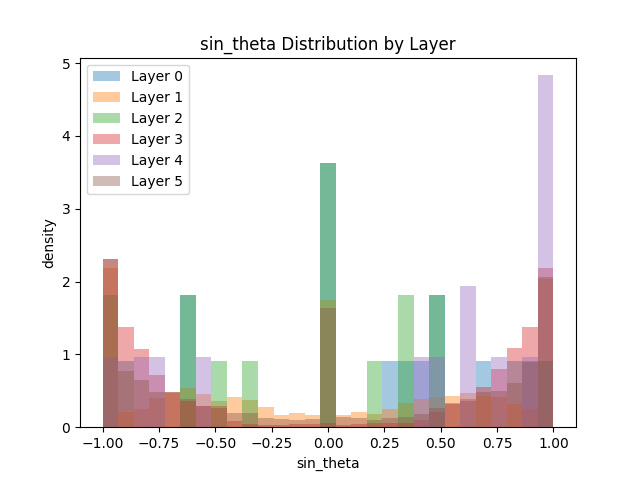

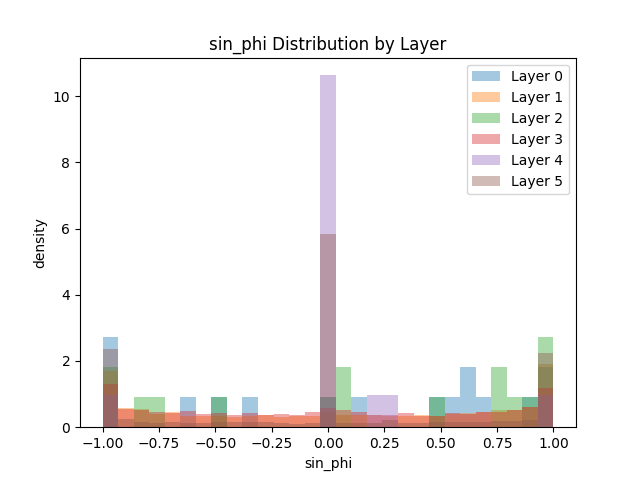

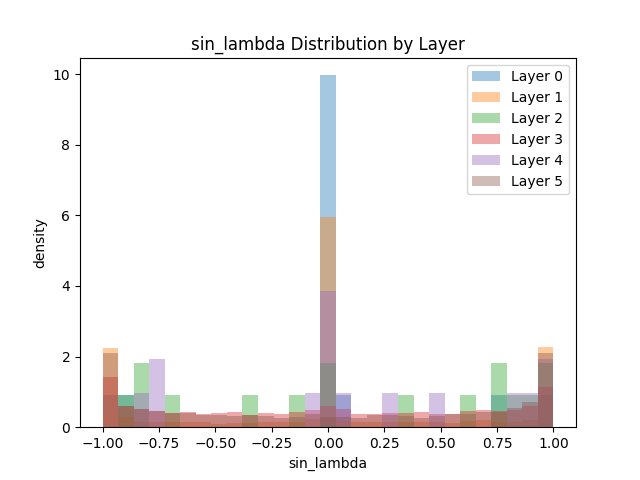

In [ ]:
for param in ["sin_theta", "sin_phi", "sin_lambda"]:
    overlay_histograms(param)


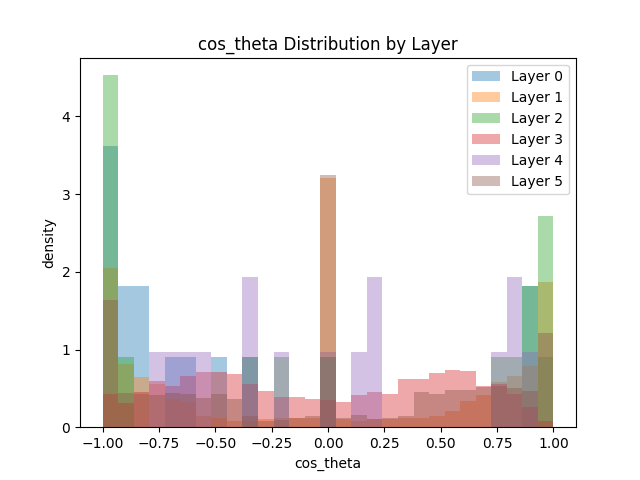

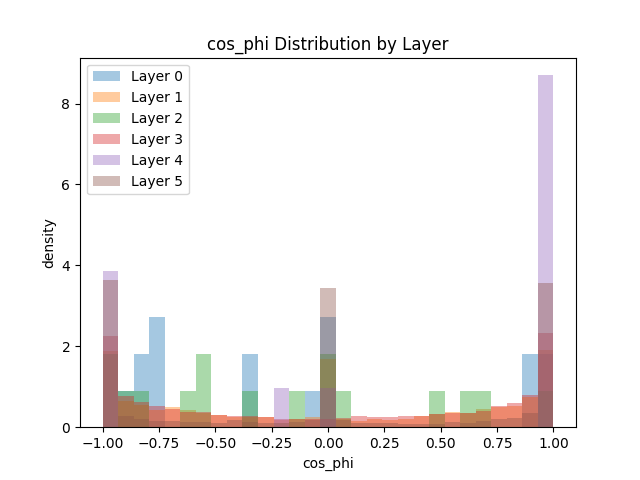

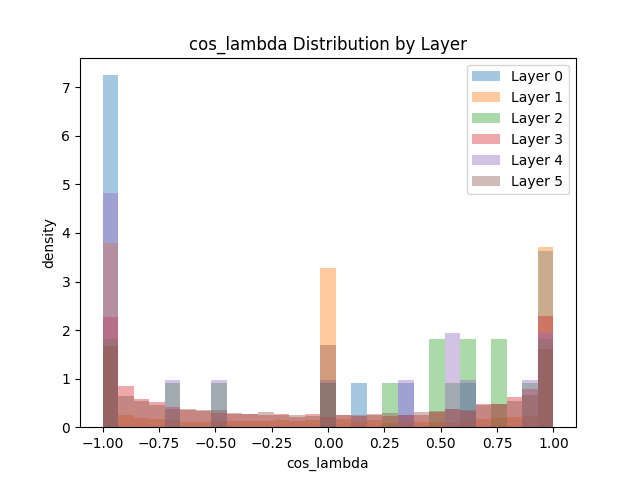

In [ ]:
for param in ["cos_theta", "cos_phi", "cos_lambda"]:
    overlay_histograms(param)


In [ ]:
df.groupby("diagram")["theta"].std()

diagram
(10, 10, 2, 1)         1.336212
(10, 2, 1)             1.310870
(10, 2, 1, 1)          1.886566
(10, 2, 1, 1, 1)       0.895203
(10, 2, 1, 1, 1, 1)    1.744787
                         ...   
(9, 9, 2, 2, 1)        1.526691
(9, 9, 3, 1)           1.552316
(9, 9, 3, 1, 1)        1.344725
(9, 9, 3, 2)           1.683120
(9, 9, 4, 1)           1.738835
Name: theta, Length: 2470, dtype: float64

In [ ]:
pivot = df.pivot_table(index=["entry", "layer"], columns="qubit", values="theta")

pivot.corr()

qubit,0,1
qubit,,
0,1.000000,0.037227
1,0.037227,1.000000


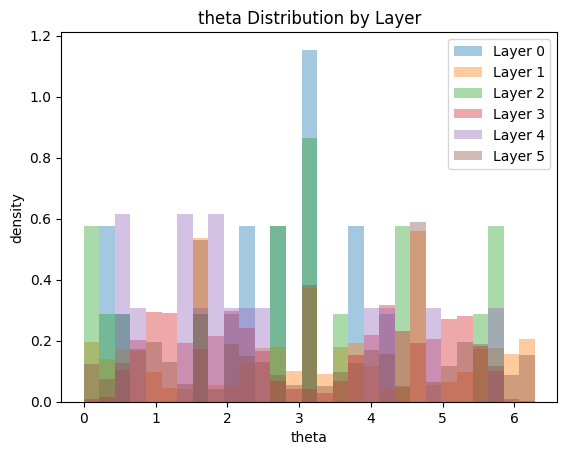

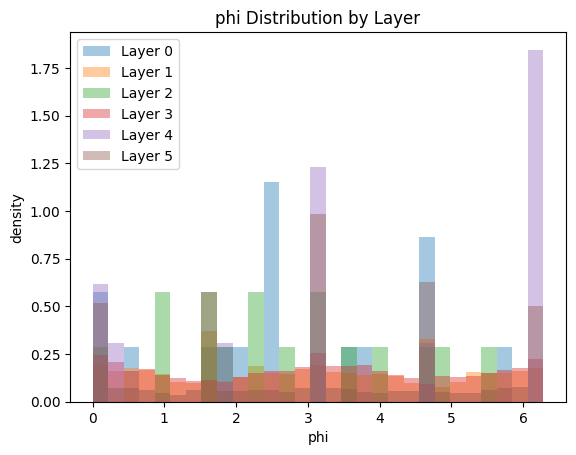

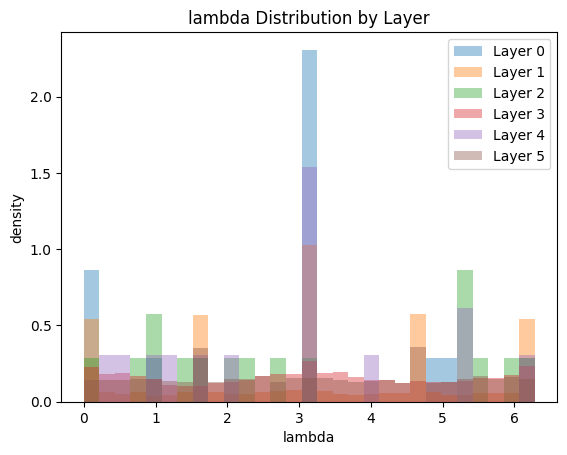

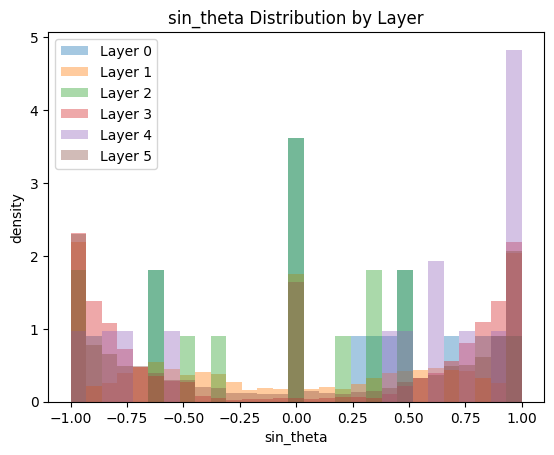

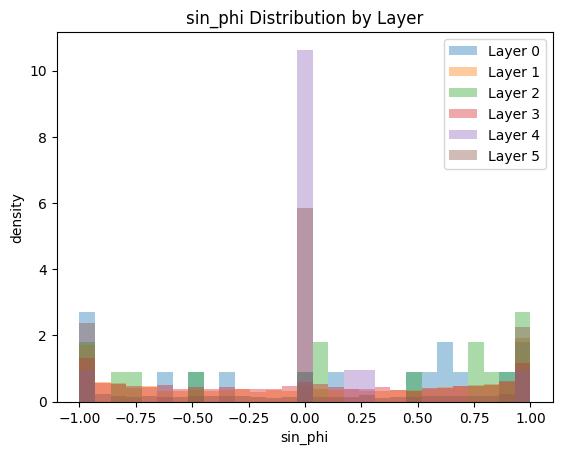

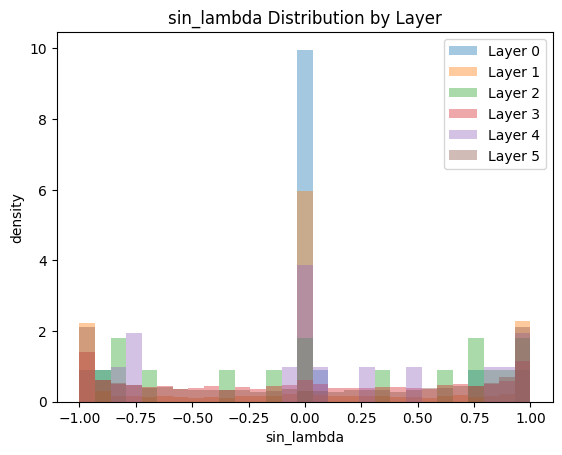

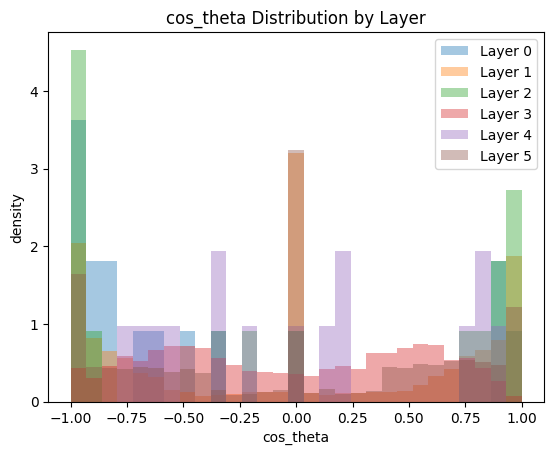

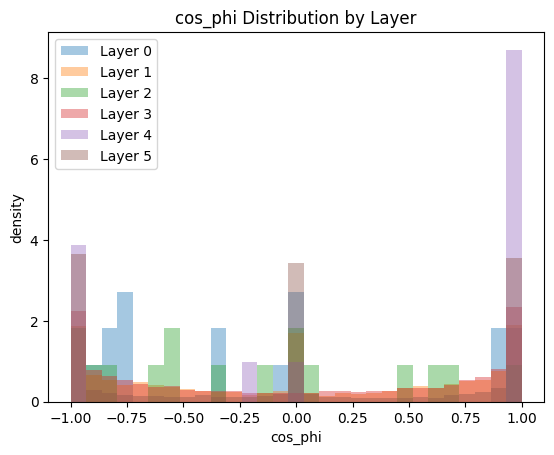

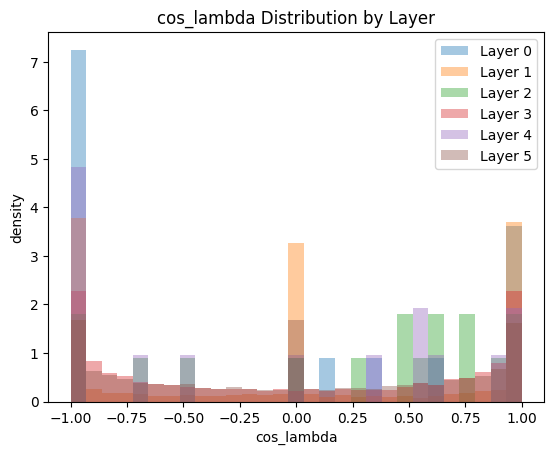

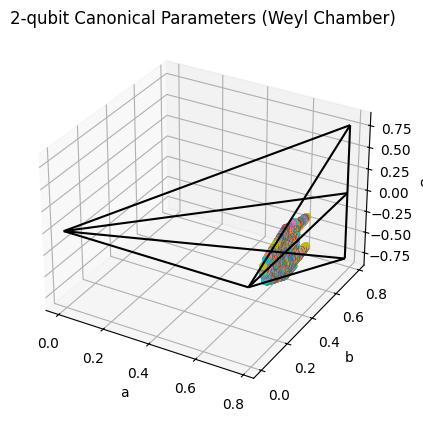

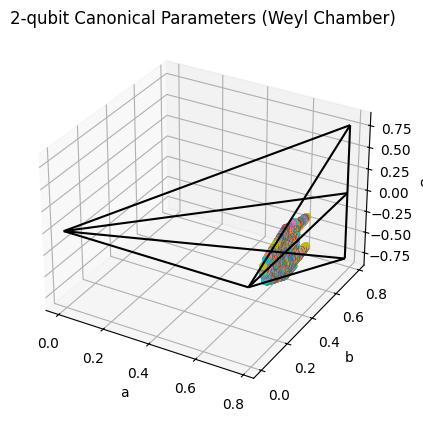

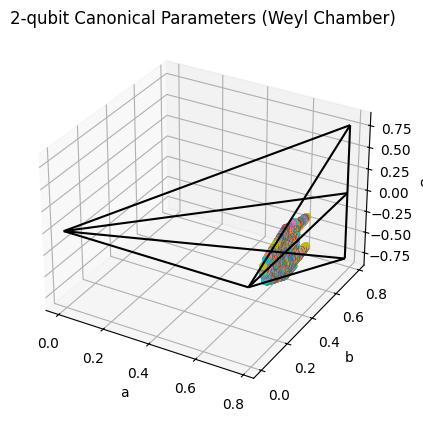

In [ ]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Scatter the data
diagrams = df["diagram"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(diagrams)))

for d, c in zip(diagrams, colors):
    subset = df[df["diagram"] == d]
    ax.scatter(
        subset["weyl_a"],
        subset["weyl_b"],
        subset["weyl_c"],
        color=c,
        label=str(d),
        alpha=0.6,
    )

# Weyl chamber vertices (Qiskit convention)
pi4 = np.pi / 4
verts = np.array(
    [[0, 0, 0], [pi4, 0, 0], [pi4, pi4, 0], [pi4, pi4, pi4], [pi4, pi4, -pi4]]
)

edges = [[0, 1], [1, 2], [2, 3], [2, 4], [0, 2], [0, 3], [0, 4], [1, 3], [1, 4]]

# Make edges into 3D lines
lines = [(verts[e[0]], verts[e[1]]) for e in edges]
lc = Line3DCollection(lines, colors="k", linewidths=1.5)
ax.add_collection3d(lc)

# Labels and title
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_zlabel("c")
ax.set_title("2-qubit Canonical Parameters (Weyl Chamber)")

plt.show()


In [ ]:
import numpy as np

points = df[["weyl_a", "weyl_b", "weyl_c"]].values

# Center the data
points_centered = points - points.mean(axis=0)

# Compute rank
rank = np.linalg.matrix_rank(points_centered)

print("Rank:", rank)


Rank: 2


In [ ]:
df["weyl_a"]

0        0.785398
1        0.785398
2        0.785398
3        0.785398
4        0.785398
           ...   
14807    0.785398
14808    0.785398
14809    0.785398
14810    0.785398
14811    0.785398
Name: weyl_a, Length: 14812, dtype: float64

In [ ]:
df = pd.read_csv("data/weyl_4_addable_size_25.csv")

In [ ]:
df.head()

,index,entry,diagram,size,weyl_a,weyl_b,weyl_c
0,0,0,"(3, 2, 1)",6,0.785398,0.252680,0.088855
1,1,1,"(4, 2, 1)",7,0.785398,0.257533,0.157103
2,2,2,"(3, 2, 1, 1)",7,0.785398,0.257533,-0.135683
3,3,3,"(5, 2, 1)",8,0.785398,0.254163,0.188487
4,4,4,"(4, 3, 1)",8,0.785398,0.204707,0.116587


In [ ]:
df[["size", "weyl_a", "weyl_b", "weyl_c"]].groupby("size").mean()

,weyl_a,weyl_b,weyl_c
size,,,
6,0.785398,0.252680,0.088855
7,0.785398,0.257533,0.010710
8,0.785398,0.235779,-0.017595
9,0.785398,0.243836,0.001358
10,0.785398,0.234757,-0.018024
11,0.785398,0.238943,-0.025629
12,0.785398,0.243742,-0.056382
13,0.785398,0.248416,-0.035468
14,0.785398,0.245664,-0.029619


(array([152., 470., 574., 624., 544., 521., 351., 153., 150.,  92.]),
 array([0.10575795, 0.14152409, 0.17729022, 0.21305636, 0.2488225 ,
        0.28458863, 0.32035477, 0.35612091, 0.39188704, 0.42765318,
        0.46341932]),
 <BarContainer object of 10 artists>)

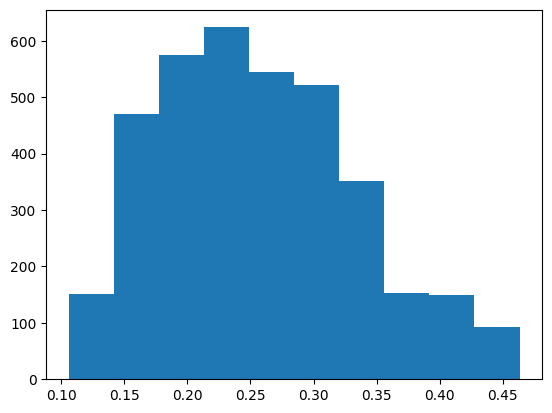

In [ ]:
plt.hist(df["weyl_b"])

(array([136., 605., 835., 301., 279., 172., 169., 466., 552., 116.]),
 array([-0.29541219, -0.23827111, -0.18113003, -0.12398895, -0.06684786,
        -0.00970678,  0.0474343 ,  0.10457539,  0.16171647,  0.21885755,
         0.27599863]),
 <BarContainer object of 10 artists>)

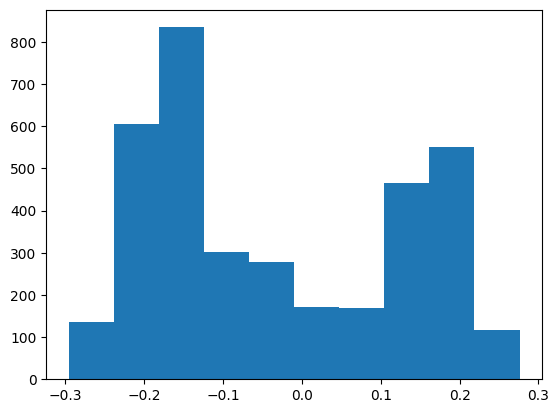

In [ ]:
plt.hist(df["weyl_c"])

(array([473., 425., 371., 390., 352., 326., 334., 336., 404., 220.]),
 array([7.04526160e-05, 6.28267901e-02, 1.25583128e-01, 1.88339465e-01,
        2.51095803e-01, 3.13852140e-01, 3.76608478e-01, 4.39364815e-01,
        5.02121153e-01, 5.64877490e-01, 6.27633828e-01]),
 <BarContainer object of 10 artists>)

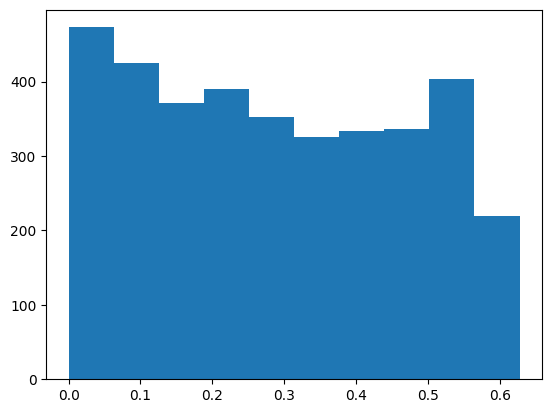

In [ ]:
plt.hist(df["weyl_b"] - df["weyl_c"])

In [ ]:
df.describe()

,index,entry,size,weyl_a,weyl_b,weyl_c
count,3631.000000,3631.000000,3631.000000,3.631000e+03,3631.000000,3631.000000
mean,1815.000000,1815.000000,21.135775,7.853982e-01,0.256305,-0.032630
std,1048.323741,1048.323741,3.545535,1.729989e-16,0.077185,0.158053
min,0.000000,0.000000,6.000000,7.853982e-01,0.105758,-0.295412
25%,907.500000,907.500000,19.000000,7.853982e-01,0.195668,-0.174121
50%,1815.000000,1815.000000,22.000000,7.853982e-01,0.248739,-0.077297
75%,2722.500000,2722.500000,24.000000,7.853982e-01,0.308706,0.137883
max,3630.000000,3630.000000,25.000000,7.853982e-01,0.463419,0.275999


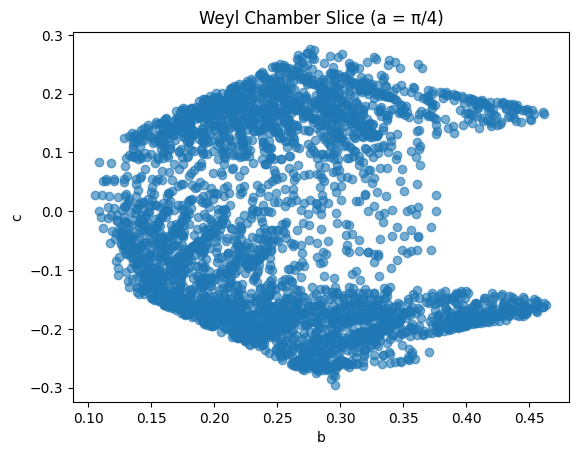

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

b = df["weyl_b"].values
c = df["weyl_c"].values

plt.figure()
plt.scatter(b, c, alpha=0.6)

plt.xlabel("b")
plt.ylabel("c")
plt.title("Weyl Chamber Slice (a = π/4)")
plt.show()


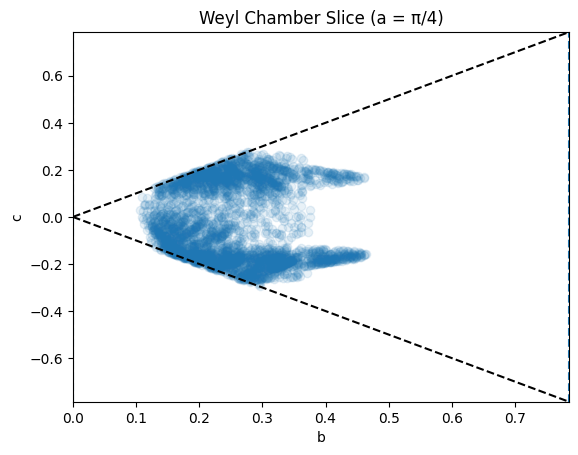

In [ ]:
pi4 = np.pi / 4

plt.figure()
plt.scatter(b, c, alpha=0.1)

# Boundary lines
b_vals = np.linspace(0, pi4, 200)

plt.plot(b_vals, b_vals, "k--")  # c = b
plt.plot(b_vals, -b_vals, "k--")  # c = -b
plt.axvline(pi4, linestyle="--")  # b = π/4
plt.axvline(0, linestyle="--")

plt.xlabel("b")
plt.ylabel("c")
plt.title("Weyl Chamber Slice (a = π/4)")
plt.xlim(0, pi4)
plt.ylim(-pi4, pi4)

plt.show()


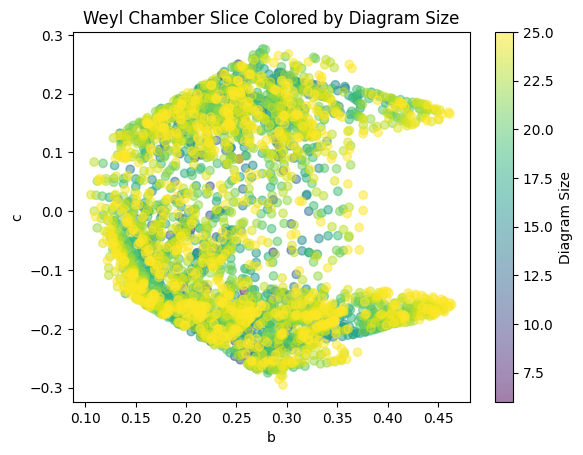

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

b = df["weyl_b"].values
c = df["weyl_c"].values
sizes = df["size"].values  # change if column name differs

plt.figure()

sc = plt.scatter(b, c, c=sizes, cmap="viridis", alpha=0.5)

plt.xlabel("b")
plt.ylabel("c")
plt.title("Weyl Chamber Slice Colored by Diagram Size")

plt.colorbar(sc, label="Diagram Size")

plt.show()


In [ ]:
np.corrcoef(df["weyl_b"], np.abs(df["weyl_c"]))

array([[1.        , 0.41672241],
       [0.41672241, 1.        ]])

In [ ]:
import numpy as np

b = df["weyl_b"].values
c_abs = np.abs(df["weyl_c"].values)

coeff = np.polyfit(b, c_abs, 1)
print("Slope:", coeff[0])


Slope: 0.3339162439388493


In [ ]:
from sklearn.decomposition import PCA

points = df[["weyl_a", "weyl_b", "weyl_c"]].values
pca = PCA(n_components=3)
pca.fit(points)

print(pca.explained_variance_ratio_)


[0.80852056 0.19147944 0.        ]


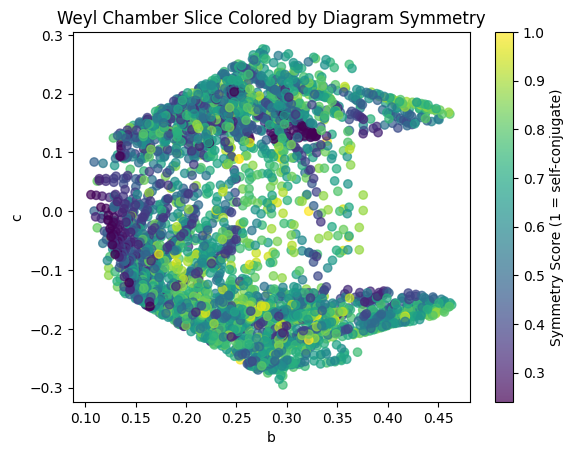

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast  # safe literal parsing

# --- Helper functions ---


def transpose_partition(part):
    max_len = max(part)
    return [sum(1 for p in part if p > i) for i in range(max_len)]


def symmetry_score(part):
    part_t = transpose_partition(part)

    # pad to equal length
    m = max(len(part), len(part_t))
    p = np.array(list(part) + [0] * (m - len(part)))
    pt = np.array(list(part_t) + [0] * (m - len(part_t)))

    d = np.sum(np.abs(p - pt))
    n = np.sum(p)

    return 1 - d / (2 * n)


# --- Parse diagram column into tuples ---
df["diagram_tuple"] = df["diagram"].apply(ast.literal_eval)

# --- Compute symmetry score ---
df["symmetry_score"] = df["diagram_tuple"].apply(symmetry_score)

# --- Scatter plot ---
plt.figure()

sc = plt.scatter(
    df["weyl_b"], df["weyl_c"], c=df["symmetry_score"], cmap="viridis", alpha=0.7
)

plt.xlabel("b")
plt.ylabel("c")
plt.title("Weyl Chamber Slice Colored by Diagram Symmetry")

plt.colorbar(sc, label="Symmetry Score (1 = self-conjugate)")

plt.show()


In [33]:
from qiskit.synthesis import TwoQubitWeylDecomposition

cnot = bqskit.ir.gates.CNOTGate().get_unitary()

TwoQubitWeylDecomposition(cnot)

TwoQubitWeylDecomposition.from_bytes(
    # TwoQubitWeylDecomposition [specialization=ControlledEquiv] (
    # 	global phase: 5π/4
    # 	     ┌─────────────┐┌────────────┐┌─────────────┐
    # 	q_0: ┤ Rx(-1.6048) ├┤0           ├┤ Rx(-3.1076) ├────────────
    # 	     └─┬─────────┬─┘│  Rxx(-π/2) │└─┬─────────┬─┘┌──────────┐
    # 	q_1: ──┤ Ry(π/2) ├──┤1           ├──┤ Rx(π/2) ├──┤ Ry(-π/2) ├
    # 	       └─────────┘  └────────────┘  └─────────┘  └──────────┘
    # )
    b'k05VTVBZAQB2AHsnZGVzY3InOiAnPGMxNicsICdmb3J0cmFuX29yZGVyJzogRmFsc2UsICdzaGFw'
    b'ZSc6ICg0LCA0KSwgfSAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAg'
    b'ICAgICAgICAgICAgIAoAAAAAAADwPwAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
    b'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAPA/AAAAAAAAAAAAAAAA'
    b'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
    b'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAPA/AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
    b'AAAAAAAAAAAAAAAAAA

In [35]:
yd = YoungDiagram([6, 4, 2])

yd_mat = A_matrix(yd)

TwoQubitWeylDecomposition(yd_mat)

TwoQubitWeylDecomposition.from_bytes(
    # TwoQubitWeylDecomposition [specialization=General] (
    # 	global phase: π/4
    # 	     ┌─────────────┐ ┌────────┐              ┌────────────┐┌────────────────┐               ┌────────────┐ ┌─────────┐┌──────────┐
    # 	q_0: ┤ Ry(-1.6609) ├─┤ Rz(-π) ├──────────────┤0           ├┤0               ├─■─────────────┤ Rz(1.1062) ├─┤ Ry(π/2) ├┤ Rz(-π/2) ├
    # 	     └─┬──────────┬┘┌┴────────┤┌────────────┐│  Rxx(-π/2) ││  Ryy(-0.46036) │ │ZZ(-0.2411) ┌┴────────────┴┐└─────────┘└──────────┘
    # 	q_1: ──┤ Rz(-π/2) ├─┤ Ry(π/2) ├┤ Rz(1.0339) ├┤1           ├┤1               ├─■────────────┤ Ry(-0.60691) ├───────────────────────
    # 	       └──────────┘ └─────────┘└────────────┘└────────────┘└────────────────┘              └──────────────┘
    # )
    b'k05VTVBZAQB2AHsnZGVzY3InOiAnPGMxNicsICdmb3J0cmFuX29yZGVyJzogRmFsc2UsICdzaGFw'
    b'ZSc6ICg0LCA0KSwgfSAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAg'
    b'ICAgICAgICAgICAgIAp6xiO6epvaP

In [ ]:
import qiskit

np.array(qiskit.circuit.library.RXXGate(-np.pi / 2).to_matrix())

array([[0.70710678+0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.70710678j],
       [0.        +0.j        , 0.70710678+0.j        ,
        0.        +0.70710678j, 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.70710678j,
        0.70710678+0.j        , 0.        +0.j        ],
       [0.        +0.70710678j, 0.        +0.j        ,
        0.        +0.j        , 0.70710678+0.j        ]])

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from scipy.linalg import expm


def ansatz(x: float, y: float):
    qc = QuantumCircuit(2)

    # qc.z(0)
    # qc.z(1)

    # qc.sx(0).inverse()
    # qc.sx(1).inverse()

    qc.cx(0, 1)

    qc.rx(x, 0)
    qc.rz(y, 1)

    qc.cx(0, 1)

    # qc.sx(0)
    # qc.sx(1)

    # qc.z(0)
    # qc.z(1)

    return Operator(qc).data


yd = YoungDiagram([5, 4, 1])
yd_mat = A_matrix(yd)
decomp = TwoQubitWeylDecomposition(yd_mat)

# get the Weyl decomposition parameters
a, b, c = decomp.a, decomp.b, decomp.c

# Pauli matrices
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# construct tensor products
XX = np.kron(X, X)
YY = np.kron(Y, Y)
ZZ = np.kron(Z, Z)

# entangling structure as unitary
entangling_structure = expm(1j * (a * XX + b * YY + c * ZZ))


def same_up_to_phase(U1, U2, atol=1e-2):
    # normalize by U1[0,0] to remove global phase
    phase = U1[0, 0] / abs(U1[0, 0])
    return np.allclose(U1, U2 * phase, atol=atol)


for a in np.linspace(0, 2 * np.pi, 100):
    for b in np.linspace(0, 2 * np.pi, 100):
        guess = ansatz(a, b)
        if same_up_to_phase(guess, entangling_structure):
            print("HOLY SHIT")
            print(a, b)


In [ ]:
dir(decomp)

['K1l',
 'K1r',
 'K2l',
 'K2r',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_inner_decomposition',
 '_specializations',
 'a',
 'actual_fidelity',
 'b',
 'c',
 'calculated_fidelity',
 'circuit',
 'from_bytes',
 'global_phase',
 'requested_fidelity',
 'specialize',
 'unitary_matrix']

In [ ]:
decomp.unitary_matrix

array([[ 0.46770717+0.j,  0.79876206+0.j,  0.36975499+0.j,
         0.08068715+0.j],
       [ 0.32274861+0.j, -0.55119819+0.j,  0.76546554+0.j,
         0.0779512 +0.j],
       [ 0.55901699+0.j, -0.19094065+0.j, -0.44194174+0.j,
         0.67507716+0.j],
       [ 0.60380736+0.j, -0.14731391+0.j, -0.28641098+0.j,
        -0.72916667+0.j]])

In [ ]:
np.linalg.det(yd_mat)

np.float64(-1.0)

In [81]:
import numpy as np
from bqskit.ir import Circuit
from bqskit.ir.gates import U3Gate, RXXGate, RYYGate, RZZGate, SqrtCNOTGate
from bqskit.ir.gates.constant import ConstantUnitaryGate


import numpy as np


# rxx = RXXGate().get_unitary([-np.pi / 2])
# fixed_rxx = ConstantUnitaryGate(rxx)

# Create empty 3-qubit circuit
circ = Circuit(3)

# ----- Front layer of U3 gates (3 parameters each) -----
for q in range(3):
    circ.append_gate(U3Gate(), [q])

# ----- Entangling layers between all pairs -----
pairs = [(0, 1), (0, 2), (1, 2)]
# pairs = [(0, 1), (1, 2)]
# pairs = [(0, 1)]

for i, j in pairs:
    # circ.append_gate(fixed_rxx, [i, j])  # fixed
    # circ.append_gate(RXXGate(), [i, j])  # fixed
    # circ.append_gate(RYYGate(), [i, j])  # parameter b_ij
    # circ.append_gate(RZZGate(), [i, j])  # parameter c_ij
    circ.append_gate(SqrtCNOTGate(), [i, j])

for q in range(3):
    circ.append_gate(U3Gate(), [q])

# for i, j in pairs:
#     # circ.append_gate(fixed_rxx, [i, j])
#     circ.append_gate(RXXGate(), [i, j])
#     circ.append_gate(RYYGate(), [i, j])
#     circ.append_gate(RZZGate(), [i, j])

# for q in range(3):
#     circ.append_gate(U3Gate(), [q])

# for i, j in pairs:
#     circ.append_gate(RXXGate(), [i, j])
#     # circ.append_gate(fixed_rxx, [i, j])
#     circ.append_gate(RYYGate(), [i, j])
#     circ.append_gate(RZZGate(), [i, j])

# for q in range(3):
#     circ.append_gate(U3Gate(), [q])

In [82]:
circ

Circuit(3)
	[U3Gate([0.0, 0.0, 0.0])@(0,), U3Gate([0.0, 0.0, 0.0])@(1,), U3Gate([0.0, 0.0, 0.0])@(2,)]
	[SqrtCNOTGate@(0, 1), SqrtCNOTGate@(0, 1), None]
	[SqrtCNOTGate@(0, 2), None, SqrtCNOTGate@(0, 2)]
	[U3Gate([0.0, 0.0, 0.0])@(0,), SqrtCNOTGate@(1, 2), SqrtCNOTGate@(1, 2)]
	[None, U3Gate([0.0, 0.0, 0.0])@(1,), U3Gate([0.0, 0.0, 0.0])@(2,)]

In [83]:
yd = YoungDiagram([7, 6, 5, 4, 3, 2, 1])

target = A_matrix(yd)
# print(target)

# TwoQubitWeylDecomposition(yd_mat)
maybe = circ.instantiate(target)


In [84]:
np.linalg.norm(maybe.get_unitary() - target)

np.float64(1.5654046615345456)

In [86]:
compiled = bqskit.compile(target, optimization_level=1)


/Users/nate/code/fourier/.venv/lib/python3.13/site-packages/bqskit/passes/synthesis/leap.py:358: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  m, y_int, _, _, _ = linregress(best_layers, best_dists)


In [ ]:
print(compiled.multi_qudit_depth)
print(bqskit_to_qiskit(compiled))

15
     ┌────────────────────────────┐                                        »
q_0: ┤ U3(8.1676,0.56733,0.68228) ├────────────────────────────────────────»
     └┬──────────────────────────┬┘         ┌───────────────────┐          »
q_1: ─┤ U3(8.1086,6.9067,5.3646) ├───■──────┤ U3(1.422,2.071,0) ├───────■──»
      ├──────────────────────────┤ ┌─┴─┐┌───┴───────────────────┴────┐┌─┴─┐»
q_2: ─┤ U3(4.8006,4.6339,3.0509) ├─┤ X ├┤ U3(2.4742,-0.55963,2.4683) ├┤ X ├»
      └──────────────────────────┘ └───┘└────────────────────────────┘└───┘»
«                                                                          »
«q_0: ──────────────────────────────────────────────────────────────────■──»
«         ┌────────────────────┐          ┌───────────────────────┐   ┌─┴─┐»
«q_1: ────┤ U3(1.898,2.2137,0) ├─────■────┤ U3(2.1366,-1.0315,-π) ├───┤ X ├»
«     ┌───┴────────────────────┴──┐┌─┴─┐┌─┴───────────────────────┴──┐└───┘»
«q_2: ┤ U3(1.5583,-2.9284,1.6286) ├┤ X ├┤ U3(1.6111,-0.70356,4.7598) ├───

In [ ]:
print(compiled.multi_qudit_depth)
print(bqskit_to_qiskit(compiled))

14
                                         ┌──────────────────────────┐      »
q_0: ────────────────────────────────■───┤ U3(4.1332,3.8894,1.4735) ├──────»
     ┌────────────────────────────┐┌─┴─┐┌┴──────────────────────────┴┐     »
q_1: ┤ U3(0.99928,1.014,-0.64109) ├┤ X ├┤ U3(-0.62353,4.2718,6.6482) ├──■──»
     └┬──────────────────────────┬┘└───┘└────────────────────────────┘┌─┴─┐»
q_2: ─┤ U3(4.8677,6.4085,3.2885) ├────────────────────────────────────┤ X ├»
      └──────────────────────────┘                                    └───┘»
«                                        ┌──────────────────────────┐     »
«q_0: ────────────────────────────────■──┤ U3(2.6393,1.3202,3.9968) ├─────»
«     ┌────────────────────────────┐┌─┴─┐├──────────────────────────┤     »
«q_1: ┤ U3(0.66869,6.1539,0.67496) ├┤ X ├┤ U3(3.3655,1.9289,5.1118) ├──■──»
«     ├───────────────────────────┬┘└───┘└──────────────────────────┘┌─┴─┐»
«q_2: ┤ U3(2.0021,5.9061,0.18326) ├──────────────────────────────────┤ X ├»
« 

In [ ]:
print(compiled.multi_qudit_depth)
print(bqskit_to_qiskit(compiled))

13
     ┌───────────────────────────────┐         ┌───────────────────┐         »
q_0: ┤ U3(6.8335,3.1416,-4.6962e-09) ├──■──────┤ U3(1.9147,5π/4,0) ├──────■──»
     └──────┬─────────────────┬──────┘┌─┴─┐┌───┴───────────────────┴───┐  │  »
q_1: ───────┤ U3(4.5993,π,2π) ├───────┤ X ├┤ U3(2.3025,4.4594,-1.7419) ├──┼──»
          ┌─┴─────────────────┴──┐    └───┘└───────────────────────────┘┌─┴─┐»
q_2: ─────┤ U3(-0.28412,7π/4,2π) ├──────────────────────────────────────┤ X ├»
          └──────────────────────┘                                      └───┘»
«     ┌───────────────────┐           ┌────────────────┐           »
«q_0: ┤ U3(1.5708,3π/2,0) ├──■────────┤ U3(0.7854,π,0) ├────────■──»
«     └───────────────────┘┌─┴─┐┌─────┴────────────────┴─────┐  │  »
«q_1: ─────────────────────┤ X ├┤ U3(1.9352,-1.2389,-1.4486) ├──┼──»
«      ┌──────────────────┐└───┘└────────────────────────────┘┌─┴─┐»
«q_2: ─┤ U3(π/2,0,2.4846) ├───────────────────────────────────┤ X ├»
«      └──────────────────┘   

In [ ]:
from bqskit.ir.gates import RZZGate, RXXGate, RYYGate, RZGate, RXGate, RYGate

gate_set = {RXXGate(), RYYGate(), RZZGate(), RZGate(), RXGate(), RYGate()}

num_qubits = 3
model = MachineModel(num_qubits, gate_set=gate_set)

In [ ]:
compiled = bqskit.compile(target, optimization_level=1, model=model)

print(compiled.multi_qudit_depth)
print(bqskit_to_qiskit(compiled))

/Users/nate/code/fourier/.venv/lib/python3.13/site-packages/bqskit/passes/synthesis/leap.py:358: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  m, y_int, _, _, _ = linregress(best_layers, best_dists)


11


QASM2ParseError: "<input>:63,0: 'ryy' is not defined in this scope"

In [ ]:
compiled

Circuit(3)
	[RZGate([np.float64(-1.2115014291410873)])@(0,), RZGate([np.float64(0.5652122899124654)])@(1,), RZGate([np.float64(2.968788616410749)])@(2,)]
	[RXGate([np.float64(1.5707963267948966)])@(0,), RXGate([np.float64(1.5707963267948966)])@(1,), RXGate([np.float64(1.5707963267948966)])@(2,)]
	[RZGate([np.float64(-1.953545685054821)])@(0,), RZGate([np.float64(-0.293062108136521)])@(1,), RZGate([np.float64(-0.7971913439020142)])@(2,)]
	[RXGate([np.float64(1.5707963267948966)])@(0,), RXGate([np.float64(1.5707963267948966)])@(1,), RXGate([np.float64(1.5707963267948966)])@(2,)]
	[RZGate([np.float64(3.0457225863594886)])@(0,), RZGate([np.float64(1.2346605684048182)])@(1,), RZGate([np.float64(-1.3853051664541862)])@(2,)]
	[RXXGate([np.float64(5.262745555301127)])@(0, 1), RXXGate([np.float64(5.262745555301127)])@(0, 1), None]
	[RZGate([np.float64(-1.398356398428247)])@(0,), RZGate([np.float64(-0.7324428059318775)])@(1,), None]
	[RXGate([np.float64(1.5707963267948966)])@(0,), RXGate([np.flo

In [10]:
yd = YoungDiagram([6, 4, 1])

yd_mat = A_matrix(yd)

wd = TwoQubitWeylDecomposition(yd_mat)

NameError: name 'TwoQubitWeylDecomposition' is not defined

In [ ]:
dir(wd)

['K1l',
 'K1r',
 'K2l',
 'K2r',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_inner_decomposition',
 '_specializations',
 'a',
 'actual_fidelity',
 'b',
 'c',
 'calculated_fidelity',
 'circuit',
 'from_bytes',
 'global_phase',
 'requested_fidelity',
 'specialize',
 'unitary_matrix']

In [ ]:
wd.specialize()

/var/folders/km/j9sl703d5sg05dbm4bjmklh00000gn/T/ipykernel_12848/4255805322.py:1: DeprecationWarning: The method ``qiskit.synthesis.two_qubit.two_qubit_decompose.TwoQubitWeylDecomposition.specialize()`` is deprecated as of Qiskit 1.1.0. It will be removed in the 2.0.0 release.
  wd.specialize()


NotImplementedError: 

In [ ]:
import qiskit

qiskit.__version__

'2.3.0'

In [ ]:
str(yd.partition)

'[6, 4, 1]'

In [ ]:
from sympy import symbols, sqrt, Matrix, simplify

n = symbols("n", real=True, positive=True)

M = Matrix(
    [
        [
            sqrt(n * (n + 2) / ((n - 1) * (n + 1) * (n + 3))),
            sqrt(
                n**2 * (n + 2) ** 2 * (n - 2) / ((n - 1) ** 2 * (n + 1) ** 2 * (n + 3))
            ),
            sqrt(3 * n**2 * (n + 2) / (2 * (n - 1) ** 2 * (n + 1) * (n + 3))) / n,
            sqrt(3 * n * (n + 2) ** 2 / (2 * (n + 1) ** 2 * (n - 1) * (n + 3)))
            / (n + 2),
        ],
        [
            sqrt(3 * (n - 2) / (8 * (n - 1))),
            sqrt(3 * n * (n - 2) ** 2 * (n + 2) / (8 * (n - 1) ** 2 * (n + 1)))
            / (2 - n),
            sqrt(9 * n * (n - 2) / (16 * (n - 1) ** 2)),
            sqrt(9 * (n - 2) * (n + 2) / (16 * (n - 1) * (n + 1))) / 3,
        ],
        [
            sqrt(n / (4 * (n + 1))),
            sqrt(n**2 * (n - 2) * (n + 2) / (4 * (n + 1) ** 2 * (n - 1))) / (-n),
            -sqrt(3 * n**2 / (8 * (n + 1) * (n - 1))),
            sqrt(3 * n * (n + 2) / (8 * (n + 1) ** 2)),
        ],
        [
            sqrt(3 * (n + 2) / (8 * (n + 3))),
            -sqrt(3 * n * (n + 2) ** 2 * (n - 2) / (8 * (n + 1) * (n - 1) * (n + 3)))
            / (n + 2),
            -sqrt(9 * n * (n + 2) / (16 * (n - 1) * (n + 3))) / 3,
            -sqrt(9 * (n + 2) ** 2 / (16 * (n + 1) * (n + 3))),
        ],
    ]
)

M

Matrix([
[sqrt(n)*sqrt(n + 2)*sqrt(1/(n - 1))/(sqrt(n + 1)*sqrt(n + 3)),                  n*sqrt((n - 2)/(n - 1)**2)*(n + 2)/((n + 1)*sqrt(n + 3)), sqrt(6)*sqrt(n + 2)/(2*sqrt(n + 1)*sqrt(n + 3)*Abs(n - 1)),  sqrt(6)*sqrt(n)*sqrt(1/(n - 1))/(2*(n + 1)*sqrt(n + 3))],
[                                    sqrt((3*n - 6)/(8*n - 8)), sqrt(6)*sqrt(n)*sqrt(n + 2)*Abs(n - 2)/(4*(2 - n)*sqrt(n + 1)*Abs(n - 1)),                       3*sqrt(n)*sqrt((n - 2)/(n - 1)**2)/4, sqrt((9*n - 18)/(16*n - 16))*sqrt(n + 2)/(3*sqrt(n + 1))],
[                                        sqrt(n)/sqrt(4*n + 4),                            -sqrt((n - 2)/(n - 1))*sqrt(n + 2)/(2*(n + 1)),                   -sqrt(3)*n*sqrt(1/(n - 1))/sqrt(8*n + 8),                  sqrt(6)*sqrt(n)*sqrt(n + 2)/(4*(n + 1))],
[                                 sqrt(3*n + 6)/sqrt(8*n + 24),        -sqrt(3)*sqrt(n)*sqrt((n - 2)/(n - 1))/(sqrt(n + 3)*sqrt(8*n + 8)),       -sqrt(n)*sqrt(n + 2)*sqrt(1/(16*n - 16))/sqrt(n + 3),                 -3

In [ ]:
simplify(M)

Matrix([
[sqrt(n)*sqrt(n + 2)*sqrt(1/(n - 1))/sqrt(n**2 + 4*n + 3),                  n*sqrt((n - 2)/(n - 1)**2)*(n + 2)/((n + 1)*sqrt(n + 3)),   sqrt(6*n + 12)/(2*sqrt(n**2 + 4*n + 3)*Abs(n - 1)), sqrt(6)*sqrt(n)*sqrt(1/(n - 1))/(2*(n + 1)*sqrt(n + 3))],
[                         sqrt(6)*sqrt((n - 2)/(n - 1))/4, -sqrt(6)*sqrt(n)*sqrt(n + 2)*Abs((n - 2)/(n - 1))/(4*(n - 2)*sqrt(n + 1)),                 3*sqrt(n)*sqrt((n - 2)/(n - 1)**2)/4,                sqrt((n**2 - 4)/(n - 1))/(4*sqrt(n + 1))],
[                                 sqrt(n)/(2*sqrt(n + 1)),                                       -sqrt((n**2 - 4)/(n - 1))/(2*n + 2),           -sqrt(6)*n*sqrt(1/(n - 1))/(4*sqrt(n + 1)),                 sqrt(6)*sqrt(n)*sqrt(n + 2)/(4*(n + 1))],
[                          sqrt(6*n + 12)/(4*sqrt(n + 3)),           -sqrt(6)*sqrt(n)*sqrt((n - 2)/(n - 1))/(4*sqrt(n**2 + 4*n + 3)), -sqrt(n)*sqrt(n + 2)*sqrt(1/(n - 1))/(4*sqrt(n + 3)),                     3*(-n - 2)/(4*sqrt(n**2 + 4*n + 3))]])

In [ ]:
M.subs(n, 3).eigenvals()

{1: 1,
 -1: 1,
 -5*sqrt(6)/32 - 3*sqrt(3)/16 - 3*sqrt(10)/32 + sqrt(5)/8 - I*sqrt(-15*sqrt(2) - 3*sqrt(15) + sqrt(30) + 149)/16: 1,
 -5*sqrt(6)/32 - 3*sqrt(3)/16 - 3*sqrt(10)/32 + sqrt(5)/8 + I*sqrt(-15*sqrt(2) - 3*sqrt(15) + sqrt(30) + 149)/16: 1}

In [ ]:
for i in range(4):
    row_norm = sum([M[i, j] ** 2 for j in range(4)])
    print(f"Row {i + 1} norm:", row_norm.simplify())

Row 1 norm: 1
Row 2 norm: 1
Row 3 norm: 1
Row 4 norm: 1


In [ ]:
from sympy import simplify

for j in range(4):
    col_norm = sum([M[i, j] ** 2 for i in range(4)])
    print(f"Column {j + 1} norm:", simplify(col_norm))

Column 1 norm: 1
Column 2 norm: 1
Column 3 norm: 1
Column 4 norm: 1


[[ 4.07910202e-02  9.99167693e-01  8.33337951e-05  8.30567084e-05]
 [ 6.11861060e-01 -2.50625610e-02  7.49998955e-01  2.49998958e-01]
 [ 4.99583853e-01 -2.03953404e-02 -6.12373286e-01  6.12371588e-01]
 [ 6.11864453e-01 -2.48961704e-02 -2.50001038e-01 -7.50001035e-01]]


In [ ]:
import sympy as sp
from sympy import I

# --- Magic basis transformation ---
B = 1 / sqrt(2) * Matrix([[1, 0, 0, I], [0, I, 1, 0], [0, I, -1, 0], [1, 0, 0, -I]])

# Transform M into magic basis
M_magic = simplify(B.inv() * M * B)

# --- Compute eigenvalues (diagonal of K in magic basis) ---
eigvals = M_magic.eigenvals()
eigvects = M_magic.eigenvects()

print("Eigenvalues in magic basis (gives K):")
for val in eigvals:
    print(val)

# --- Construct K matrix ---
# Eigenvalues of K = exp(i * (a X⊗X + b Y⊗Y + c Z⊗Z))
# Let λ1,λ2,λ3,λ4 = eigenvalues of M_magic
# Solve for a,b,c:
X = Matrix([[0, 1], [1, 0]])
Y = Matrix([[0, -I], [I, 0]])
Z = Matrix([[1, 0], [0, -1]])
# Tensor products
XX = sp.tensorproduct(X, X)
YY = sp.tensorproduct(Y, Y)
ZZ = sp.tensorproduct(Z, Z)

# K = exp(i*(a XX + b YY + c ZZ))
# Solve: diag(exp(i*(a+b+c)), ...) = eigenvals
# For simplicity, we can take logs of eigenvalues to get canonical angles
angles = [sp.arg(val) for val in eigvals]  # symbolic phases
# For 4x4, angles map to a,b,c up to Weyl chamber conventions
# Here, we just display them
print("\nCanonical angles (phases of K diagonal):")
print(angles)

# --- Local unitaries U1⊗U2 and V1⊗V2 ---
# Solve M = (U1⊗U2) K (V1⊗V2)
# For symbolic matrices, we can extract V as eigenvectors in magic basis
V_magic = Matrix([vect[2][0] for vect in eigvects]).T
V = simplify(B * V_magic)  # Transform back to computational basis
# Then U = M * V.inv() * K.inv()
# (For numeric n, you can compute it explicitly with numpy)

print("\nV (local unitaries on right) in computational basis:")
sp.pprint(V)

print("\n--- K and U matrices can now be reconstructed symbolically ---")

In [15]:
import sympy as sp

M_inf = M.applyfunc(lambda x: sp.limit(x, n, sp.oo))
sp.pprint(M_inf)

⎡ 0   1   0     0  ⎤
⎢                  ⎥
⎢√6                ⎥
⎢──   0  3/4   1/4 ⎥
⎢4                 ⎥
⎢                  ⎥
⎢        -√6    √6 ⎥
⎢1/2  0  ────   ── ⎥
⎢         4     4  ⎥
⎢                  ⎥
⎢√6                ⎥
⎢──   0  -1/4  -3/4⎥
⎣4                 ⎦


In [19]:
simplify(M_inf * M_inf.H)

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 0],
[0, 0, 0, 1]])

In [ ]:
import sympy as sp

# Symbols
sqrt = sp.sqrt

# --- Define the 3x3 rotation block ---
A = sp.Matrix(
    [
        [sqrt(6) / 4, 3 / sp.Integer(4), 1 / sp.Integer(4)],
        [sp.Rational(1, 2), -sqrt(6) / 4, sqrt(6) / 4],
        [sqrt(6) / 4, -sp.Rational(1, 4), -sp.Rational(3, 4)],
    ]
)

# -------------------------------------------------
# 1) Compute rotation angle using trace formula
# For SO(3): trace(A) = 1 + 2 cos(theta)
# -------------------------------------------------

traceA = sp.simplify(A.trace())
cos_theta = sp.simplify((traceA - 1) / 2)

theta = sp.acos(cos_theta)

print("Trace(A) =", traceA)
print("cos(theta) =", cos_theta)
print("Rotation angle theta =", theta)

# -------------------------------------------------
# 2) Compute rotation axis
# Axis = eigenvector with eigenvalue 1
# -------------------------------------------------

eigs = A.eigenvects()

# Find eigenvalue 1
for val, mult, vects in eigs:
    if sp.simplify(val - 1) == 0:
        axis = vects[0]
        break

axis = sp.simplify(axis)

# Normalize the axis
axis_norm = sp.sqrt(axis.dot(axis))
axis_unit = sp.simplify(axis / axis_norm)

print("\nRotation axis (unnormalized):")
sp.pprint(axis)

print("\nUnit rotation axis:")
sp.pprint(axis_unit)

Trace(A) = -3/4
cos(theta) = -7/8
Rotation angle theta = acos(-7/8)

Rotation axis (unnormalized):
⎡1 + √6 ⎤
⎢       ⎥
⎢-1 + √6⎥
⎢       ⎥
⎣   1   ⎦

Unit rotation axis:
⎡√15⋅(1 + √6) ⎤
⎢──────────── ⎥
⎢     15      ⎥
⎢             ⎥
⎢√15⋅(-1 + √6)⎥
⎢─────────────⎥
⎢     15      ⎥
⎢             ⎥
⎢     √15     ⎥
⎢     ───     ⎥
⎣     15      ⎦


In [21]:
M

Matrix([
[sqrt(n)*sqrt(n + 2)*sqrt(1/(n - 1))/(sqrt(n + 1)*sqrt(n + 3)),                  n*sqrt((n - 2)/(n - 1)**2)*(n + 2)/((n + 1)*sqrt(n + 3)), sqrt(6)*sqrt(n + 2)/(2*sqrt(n + 1)*sqrt(n + 3)*Abs(n - 1)),  sqrt(6)*sqrt(n)*sqrt(1/(n - 1))/(2*(n + 1)*sqrt(n + 3))],
[                                    sqrt((3*n - 6)/(8*n - 8)), sqrt(6)*sqrt(n)*sqrt(n + 2)*Abs(n - 2)/(4*(2 - n)*sqrt(n + 1)*Abs(n - 1)),                       3*sqrt(n)*sqrt((n - 2)/(n - 1)**2)/4, sqrt((9*n - 18)/(16*n - 16))*sqrt(n + 2)/(3*sqrt(n + 1))],
[                                        sqrt(n)/sqrt(4*n + 4),                            -sqrt((n - 2)/(n - 1))*sqrt(n + 2)/(2*(n + 1)),                   -sqrt(3)*n*sqrt(1/(n - 1))/sqrt(8*n + 8),                  sqrt(6)*sqrt(n)*sqrt(n + 2)/(4*(n + 1))],
[                                 sqrt(3*n + 6)/sqrt(8*n + 24),        -sqrt(3)*sqrt(n)*sqrt((n - 2)/(n - 1))/(sqrt(n + 3)*sqrt(8*n + 8)),       -sqrt(n)*sqrt(n + 2)*sqrt(1/(16*n - 16))/sqrt(n + 3),                 -3

In [ ]:
# Build skew-symmetric matrix from axis
nx, ny, nz = axis_unit

K = sp.Matrix([[0, -nz, ny], [nz, 0, -nx], [-ny, nx, 0]])

R = sp.eye(3) + sp.sin(theta) * K + (1 - sp.cos(theta)) * (K * K)
R_simplified = sp.simplify(R)

print("\nReconstructed rotation matrix:")
sp.pprint(R_simplified.T)


Reconstructed rotation matrix:
⎡√6             ⎤
⎢──   3/4   1/4 ⎥
⎢4              ⎥
⎢               ⎥
⎢     -√6    √6 ⎥
⎢1/2  ────   ── ⎥
⎢      4     4  ⎥
⎢               ⎥
⎢√6             ⎥
⎢──   -1/4  -3/4⎥
⎣4              ⎦


In [24]:
sp.simplify(A * axis - axis)

Matrix([
[0],
[0],
[0]])

In [1]:
import sympy
from symbolic_a_matrix import build_symbolic_a_matrix

In [2]:
A, (w1, w2, w3, h1, h2, h3) = build_symbolic_a_matrix()

In [3]:
A

Matrix([
[sqrt(h_1)*sqrt(h_1 + h_2 + w_1)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2)/(sqrt(h_1 + w_1)*sqrt(h_1 + h_2 + w_1 + w_2)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2 + w_3)),              sqrt(w_1)*sqrt(h_1 + h_2 + w_1)*sqrt(h_2 + w_1 + w_2)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2)*sqrt(h_2 + h_3 + w_1 + w_2 + w_3)/(sqrt(h_1 + w_1)*sqrt(h_2 + w_1)*sqrt(h_1 + h_2 + w_1 + w_2)*sqrt(h_2 + h_3 + w_1 + w_2)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2 + w_3)),                                      sqrt(h_1)*sqrt(h_2)*sqrt(w_2)*sqrt(h_3 + w_2 + w_3)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2)/(sqrt(h_1 + w_1)*sqrt(h_2 + w_1)*sqrt(h_3 + w_2)*sqrt(h_1 + h_2 + w_1 + w_2)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2 + w_3)),                                                  sqrt(h_1)*sqrt(h_3)*sqrt(w_3)*sqrt(h_1 + h_2 + w_1)*sqrt(h_2 + h_3 + w_2)/(sqrt(h_1 + w_1)*sqrt(h_3 + w_2)*sqrt(h_1 + h_2 + w_1 + w_2)*sqrt(h_2 + h_3 + w_1 + w_2)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2 + w_3))],
[                                                sqrt(h_2)*sqrt(w_1)*sqrt(

In [6]:
# mat = A.subs({w1: 7, w2: 5, w3: 3, h1: 1, h2: 2, h3: 3})
sympy.Trace(A).simplify()

-sqrt(h_1)*sqrt(h_2)*sqrt(h_2 + h_3 + w_2)*sqrt(h_2 + w_1 + w_2)*sqrt(h_2 + h_3 + w_1 + w_2 + w_3)/(sqrt(h_1 + w_1)*sqrt(h_2 + w_1)*sqrt(h_2 + w_2)*sqrt(h_2 + h_3 + w_1 + w_2)*sqrt(h_2 + h_3 + w_2 + w_3)) + sqrt(h_1)*sqrt(h_1 + h_2 + w_1)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2)/(sqrt(h_1 + w_1)*sqrt(h_1 + h_2 + w_1 + w_2)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2 + w_3)) - sqrt(h_2)*sqrt(h_3)*sqrt(h_1 + h_2 + w_1)*sqrt(h_2 + w_1 + w_2)*sqrt(h_3 + w_2 + w_3)/(sqrt(h_2 + w_1)*sqrt(h_2 + w_2)*sqrt(h_3 + w_2)*sqrt(h_3 + w_3)*sqrt(h_1 + h_2 + w_1 + w_2)) - sqrt(h_3)*sqrt(h_2 + h_3 + w_2)*sqrt(h_3 + w_2 + w_3)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2)*sqrt(h_2 + h_3 + w_1 + w_2 + w_3)/(sqrt(h_3 + w_2)*sqrt(h_3 + w_3)*sqrt(h_2 + h_3 + w_1 + w_2)*sqrt(h_2 + h_3 + w_2 + w_3)*sqrt(h_1 + h_2 + h_3 + w_1 + w_2 + w_3))

In [167]:
A, (w1, w2, w3, h1, h2, h3) = build_symbolic_a_matrix()
A

Matrix([
[sqrt(h_1)*sqrt((h_1 + h_2 + w_1 - w_2)*(h_1 + h_2 + h_3 + w_1 - w_3)/((h_1 + w_1 - w_2)*(h_1 + h_2 + w_1 - w_3)))/sqrt(h_1 + h_2 + h_3 + w_1), sqrt((w_1 - w_2)*(h_2 + w_1 - w_3)*(h_1 + h_2 + w_1 - w_2)*(h_1 + h_2 + h_3 + w_1 - w_3)/((h_1 + w_1 - w_2)*(h_2 + w_1 - w_2)*(h_1 + h_2 + w_1 - w_3)*(h_2 + h_3 + w_1 - w_3)))*sqrt(h_2 + h_3 + w_1)/sqrt(h_1 + h_2 + h_3 + w_1), sqrt(h_1)*sqrt(h_2)*sqrt((w_2 - w_3)*(h_1 + h_2 + h_3 + w_1 - w_3)/((h_1 + w_1 - w_2)*(h_2 + w_1 - w_2)*(h_3 + w_2 - w_3)*(h_1 + h_2 + w_1 - w_3)))*sqrt(h_3 + w_2)*Abs(h_1 + h_2 + w_1 - w_2)/(sqrt(h_1 + h_2 + h_3 + w_1)*(h_1 + h_2 + w_1 - w_2)), sqrt(h_1)*sqrt(h_3)*sqrt(w_3)*sqrt((h_1 + h_2 + w_1 - w_2)*(h_2 + h_3 + w_2 - w_3)/((h_1 + w_1 - w_2)*(h_3 + w_2 - w_3)*(h_1 + h_2 + w_1 - w_3)*(h_2 + h_3 + w_1 - w_3)))*Abs(h_1 + h_2 + h_3 + w_1 - w_3)/(sqrt(h_1 + h_2 + h_3 + w_1)*(h_1 + h_2 + h_3 + w_1 - w_3))],
[                              sqrt(h_2)*sqrt((w_1 - w_2)*(h_2 + h_3 + w_2 - w_3)/((h_1 + w_1 - w_2)*(h_2 + w

In [165]:
# mat = A.subs({w1: 7, w2: 5, w3: 3, h1: 1, h2: 2, h3: 3})
sympy.Trace(A).simplify()

-sqrt(h_1)*sqrt(h_2)*sqrt((h_2 + w_1 - w_3)*(h_2 + h_3 + w_2 - w_3)/((h_1 + w_1 - w_2)*(h_2 + w_1 - w_2)*(h_2 + w_2 - w_3)*(h_2 + h_3 + w_1 - w_3)))*sqrt(h_2 + h_3 + w_1)*Abs(w_1 - w_2)/((w_1 - w_2)*sqrt(h_2 + h_3 + w_2)) + sqrt(h_1)*sqrt((h_1 + h_2 + w_1 - w_2)*(h_1 + h_2 + h_3 + w_1 - w_3)/((h_1 + w_1 - w_2)*(h_1 + h_2 + w_1 - w_3)))/sqrt(h_1 + h_2 + h_3 + w_1) - sqrt(h_2)*sqrt(h_3)*sqrt((h_2 + w_1 - w_3)*(h_1 + h_2 + w_1 - w_2)/((h_2 + w_1 - w_2)*(h_2 + w_2 - w_3)*(h_3 + w_2 - w_3)*(h_1 + h_2 + w_1 - w_3)))*sqrt(h_3 + w_2)*Abs(w_2 - w_3)/(sqrt(h_3 + w_3)*(w_2 - w_3)) - sqrt(h_3)*sqrt((h_2 + h_3 + w_2 - w_3)*(h_1 + h_2 + h_3 + w_1 - w_3)/((h_3 + w_2 - w_3)*(h_2 + h_3 + w_1 - w_3)))*sqrt(h_3 + w_2)*sqrt(h_2 + h_3 + w_1)/(sqrt(h_3 + w_3)*sqrt(h_2 + h_3 + w_2)*sqrt(h_1 + h_2 + h_3 + w_1))